[Link](https://www.kaggle.com/datasets/fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid?resource=download)

# About Data

According to the provided information, the medical dataset classifies either heart attack or none. The gender column in the data is normalized: the male is set to 1 and the female to 0. The glucose column is set to 1 if it is > 120; otherwise, 0. As for the output, positive is set to 1 and negative to 0.

The dataset has 9 column:

- Age: The patient's age
- Gender: Biological sex of the patient (The male is set to 1 and the female to 0)
- Heart Rate: The number of heartbeats per minute
- Systolic Blood Pressure: The pressure in arteries when the heart contracts
- Diastolic Blood Pressure: The pressure in arteries between heartbeats
- Blood Sugar: The patient's blood glucose level
- Ck-mb: A cardiac enzyme released during heart muscle damage
     - 심장 근육에 존재하는 효소로, 심장 근육이 손상되면 방출된다.
- Troponin:A highly specific protein biomarker for heart muscle injury
    - 심장 근육 수축에 관여하는 단백질
- Result: The outcome label indicating whether or not the patient experienced a heart attack

# Import

In [86]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Data

In [2]:
df = pd.read_csv("../../../../delete/Medicaldataset.csv")
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [3]:
df['Result'] = df['Result'].map({'negative': 0, 'positive': 1})

In [4]:
df['Result'].value_counts()

1    810
0    509
Name: Result, dtype: int64

# EDA

- Gender

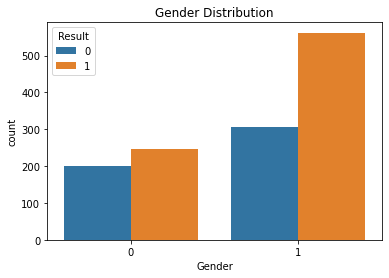

In [112]:
sns.countplot(x='Gender', hue='Result', data=df)
plt.title("Gender Distribution");

In [115]:
pd.crosstab(df['Gender'], df['Result'])

Result,0,1
Gender,,
0,201,246
1,307,562


In [117]:
pd.crosstab(df['Gender'], df['Result'], normalize='index').round(2)

Result,0,1
Gender,,
0,0.45,0.55
1,0.35,0.65


- 성별에 큰 의미가 없어보임.

- Continuous Values

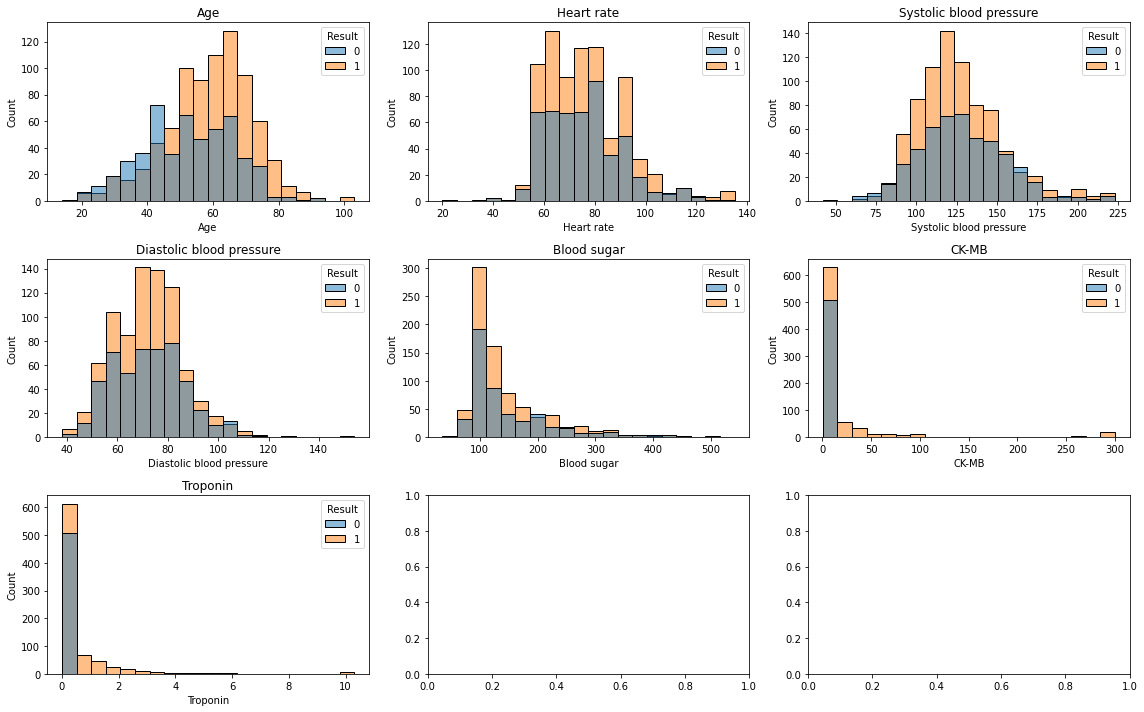

In [110]:
cols = ['Age', 'Heart rate','Systolic blood pressure','Diastolic blood pressure','Blood sugar','CK-MB','Troponin']

fig, axes = plt.subplots(3, 3, figsize=(16,10))

for i, col in enumerate(cols):
    ax = axes[i//3, i%3]
    sns.histplot(data=df, x=col, hue='Result', bins=20, ax=ax)
    ax.set_title(col)

plt.tight_layout();

- 나이가 높을수록 심장 마비 영향이 높음
- 심박수는 영향이 없어보임
- 수축기혈압 systolic blood pressure은 영향 없어 보임
- 확장기혈압 diastolic blood pressure도 영향 없어 보임.
- 혈당도 영향 없어 보임
- 심장 근육속 존재하는 효소인 CK-MB도 영향 없어보임.
- Troponin도..

- Data distribution check

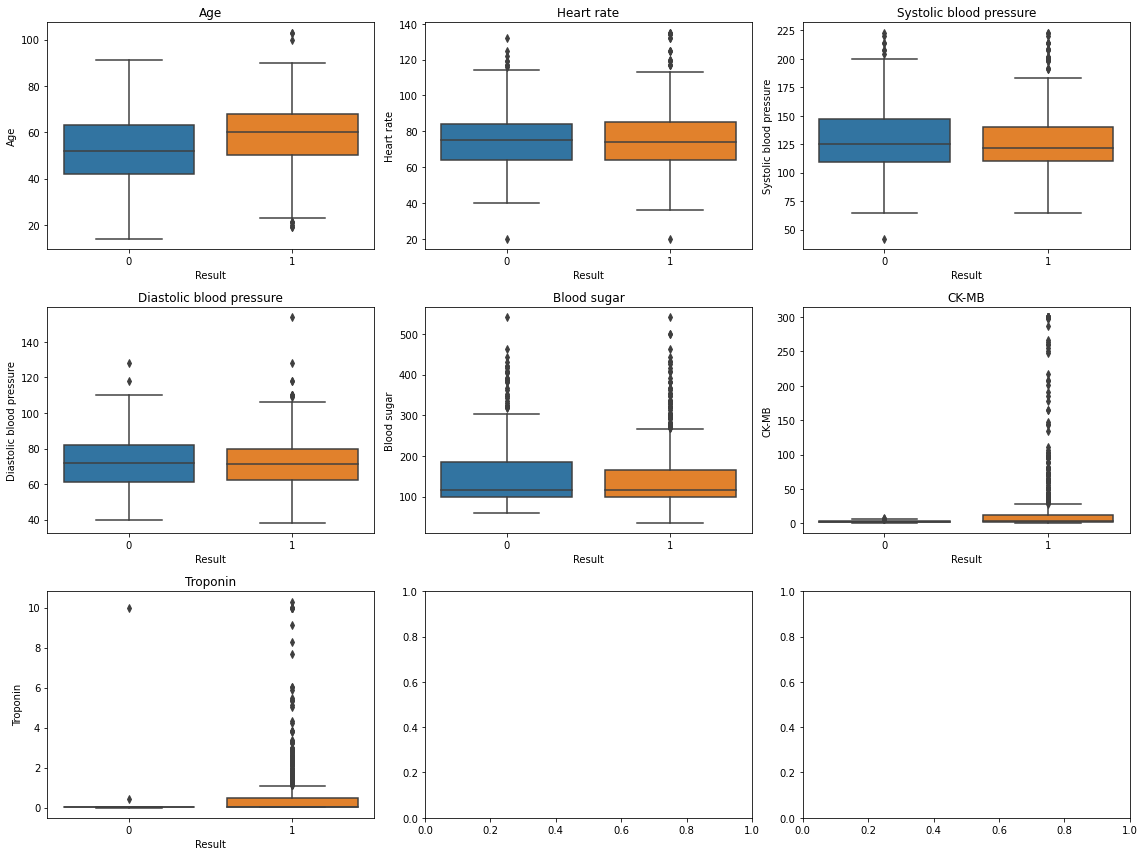

In [111]:
fig, axes = plt.subplots(3, 3, figsize=(16,12))

for i, col in enumerate(cols):
    ax = axes[i//3, i%3]
    sns.boxplot(x='Result', y=col, data=df, ax=ax)
    ax.set_title(col)

plt.tight_layout();

- 모두 심장마비 유무에 평균 차이가 없어보이나 이상치나 skewed된 모습이 보임

In [119]:
df.groupby('Result')[cols].mean().round(2)

,Age,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
Result,,,,,,,
0,52.13,75.85,127.83,72.40,149.89,2.56,0.03
1,58.77,76.06,126.70,72.11,144.72,23.32,0.57


- ttest

In [9]:
for col in cols:
    g0 = df[df['Result']==0][col]
    g1 = df[df['Result']==1][col]

    t,p = ttest_ind(g0,g1)
    print(col, "p-value:", round(p,2))

Heart rate p-value: 0.8
Systolic blood pressure p-value: 0.45
Diastolic blood pressure p-value: 0.73
Blood sugar p-value: 0.23
CK-MB p-value: 0.0
Troponin p-value: 0.0


- CK-MB, Troponin만 유의한 차이가 있음

- data outliers

Values outside physiologically plausible ranges (e.g., heart rate > 250 bpm) were treated as data entry errors and set to missing.

In [10]:
df['Heart rate'].describe()

count    1319.000000
mean       78.336619
std        51.630270
min        20.000000
25%        64.000000
50%        74.000000
75%        85.000000
max      1111.000000
Name: Heart rate, dtype: float64

In [11]:
df.sort_values('Heart rate', ascending=False).head(5)

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
1069,32,0,1111,141,95,82.0,2.66,0.008,0
717,70,0,1111,141,95,138.0,3.87,0.028,1
63,45,1,1111,141,95,109.0,1.33,1.010,1
682,68,1,135,98,60,96.0,254.40,0.025,1
1012,65,1,135,98,60,162.0,7.67,0.025,1


In [12]:
df = df[df['Heart rate'] < 250]

# Logistic Regression

<Axes: >

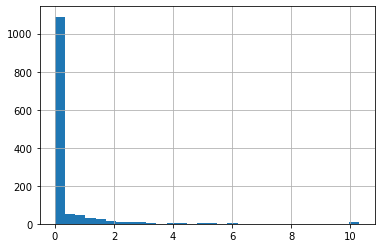

In [47]:
df['Troponin'].hist(bins=30)

In [48]:
X = df[['Age','Gender','Heart rate',
        'Systolic blood pressure',
        'Diastolic blood pressure',
        'Blood sugar','CK-MB','Troponin']]

y = df['Result']

- train/test split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- model

In [50]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

- prediction

In [51]:
y_pred = model.predict(X_test)

- score

In [52]:
print("Accuracy:", round(accuracy_score(y_test, y_pred),2))
y_prob = model.predict_proba(X_test)[:,1]
print("ROC AUC:", round(roc_auc_score(y_test, y_prob),2))

Accuracy: 0.81
ROC AUC: 0.88


In [53]:
coef = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
})

In [54]:
print(round(coef,2))

                   Variable  Coefficient  Odds Ratio
0                       Age         0.05        1.05
1                    Gender         0.45        1.57
2                Heart rate         0.00        1.00
3   Systolic blood pressure        -0.00        1.00
4  Diastolic blood pressure         0.00        1.00
5               Blood sugar        -0.00        1.00
6                     CK-MB         0.35        1.42
7                  Troponin         6.84      932.77


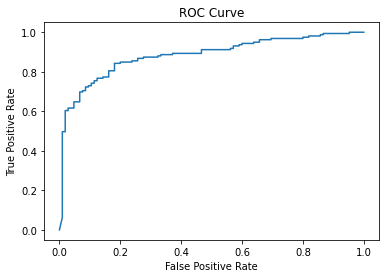

In [57]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve");

# MLP, Multi-layer Perceptron

In [87]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [89]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [95]:
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
27/27 [==============================] - 0s 3ms/step - loss: 0.4792 - accuracy: 0.7539 - val_loss: 0.4921 - val_accuracy: 0.7488
Epoch 2/50
27/27 [==============================] - 0s 3ms/step - loss: 0.4714 - accuracy: 0.7693 - val_loss: 0.4865 - val_accuracy: 0.7488
Epoch 3/50
27/27 [==============================] - 0s 4ms/step - loss: 0.4630 - accuracy: 0.7741 - val_loss: 0.4784 - val_accuracy: 0.7583
Epoch 4/50
27/27 [==============================] - 0s 4ms/step - loss: 0.4552 - accuracy: 0.7836 - val_loss: 0.4770 - val_accuracy: 0.7488
Epoch 5/50
27/27 [==============================] - 0s 3ms/step - loss: 0.4469 - accuracy: 0.7895 - val_loss: 0.4674 - val_accuracy: 0.7536
Epoch 6/50
27/27 [==============================] - 0s 4ms/step - loss: 0.4395 - accuracy: 0.7848 - val_loss: 0.4623 - val_accuracy: 0.7488
Epoch 7/50
27/27 [==============================] - 0s 3ms/step - loss: 0.4332 - accuracy: 0.7919 - val_loss: 0.4594 - val_accuracy: 0.7630
Epoch 8/50
27/27 [==

In [96]:
y_pred = model.predict(X_test)

9/9 [==============================] - 0s 891us/step


In [97]:
y_pred_class = (y_pred > 0.5).astype(int)

In [98]:
print('accuracy: ',round(accuracy_score(y_test, y_pred_class),2))

accuracy:  0.78


In [99]:
print('roc: ',round(roc_auc_score(y_test, y_pred),2))

roc:  0.87
